In [ ]:
import pandas as pd
import zipfile
import os

# Αποσυμπίεση
zip_path = '/content/reduced_datasets.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/reduced_data/')

# Προβολή αρχείων στον φάκελο
os.listdir('/content/reduced_data/')

os.listdir('/content/reduced_data/content/preterm_dataset_versions/')

# Φόρτωση τελικού αρχείου
df = pd.read_excel('/content/reduced_data/content/preterm_dataset_versions/reduced_preterm_dataset_1.xlsx')

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,39.454795,31.428571,81.205926,0.805,1.20,4.9,2.01,1.00,168.0,0.97,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Κανονικοποίηση (μετασχηματισμός των δεδομένων ώστε να έχουν μέσο όρο 0 και τυπική απόκλιση 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)

# 10-Fold Cross-Validation για internal validation
# n_neighbors=5: αριθμός γειτόνων (συνήθης χρήση αυτής της τιμής)
knn = KNeighborsClassifier(n_neighbors=5)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(knn, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
knn.fit(X_train_balanced, y_train_balanced)
y_pred = knn.predict(X_test_scaled) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = knn.predict_proba(X_test_scaled)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.9335
PRECISION: 0.8961
RECALL: 0.9823
F1: 0.9368
ROC_AUC: 0.9823
AVERAGE_PRECISION: 0.9703

Confusion Matrix:
 [[173  20]
 [  8  39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       193
           1       0.66      0.83      0.74        47

    accuracy                           0.88       240
   macro avg       0.81      0.86      0.83       240
weighted avg       0.90      0.88      0.89       240


ROC AUC Score: 0.9175945320251351

PR AUC Score: 0.7686506724957984


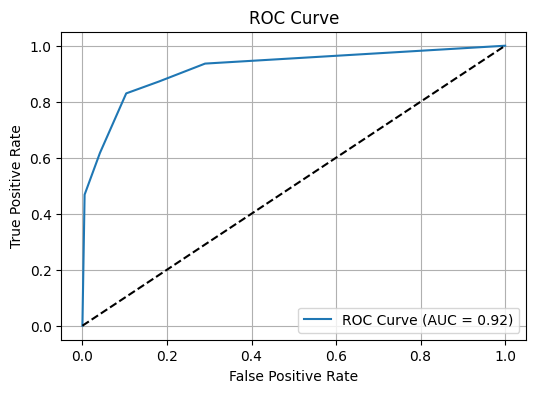

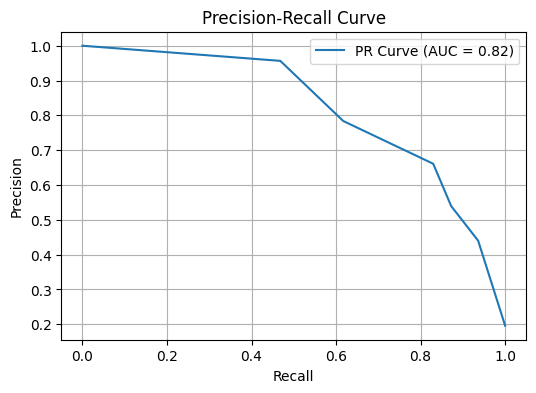

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου KNN Regression με κανονικοποίηση
# StandarScaler(): κανονικοποιεί τα χαρακτηριστικά ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1
# n_neighbors=5: πρόβλεψη με βάση τις τιμές των 5 πιο κοντινών γειτόνων (συνήθης χρήση αυτής της τιμής)
knn_reg = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(knn_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
knn_reg.fit(X_train, y_train)

# Προβλέψεις στο test set
y_pred = knn_reg.predict(X_test)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Cross-Validation Results:
R²: 0.4134
MAE: 1.3697
MSE: 4.3322
RMSE: 2.0814

Evaluation on Test Set:
R² Score: 0.3800
MAE: 1.4164
MSE: 4.9095
RMSE: 2.2157


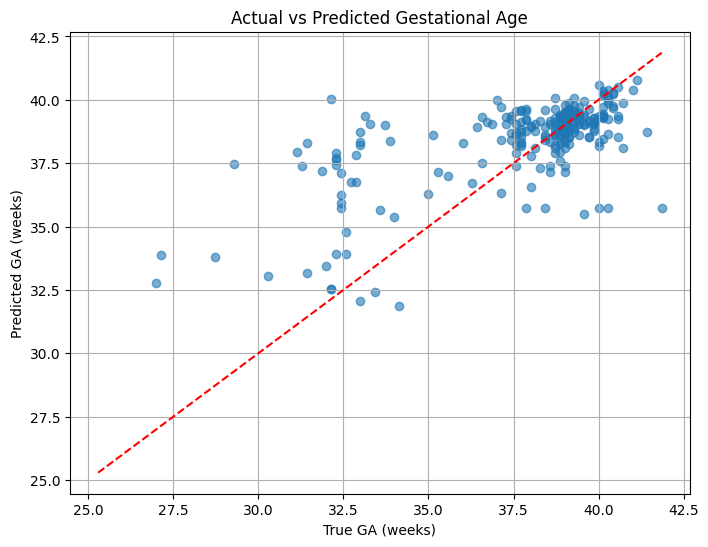

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("True GA (weeks)")
plt.ylabel("Predicted GA (weeks)")
plt.title("Actual vs Predicted Gestational Age")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Διαγώνια γραμμή
plt.grid(True)
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Δημιουργία pipeline με StandardScaler (κανονικοποίηση) και K-Neighbors Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'knn__n_neighbors': [3, 5, 7, 9]: αριθμός γειτόνων
# 'knn__weights': ['uniform', 'distance']: uniform = όλοι οι γείτονες έχουν ίδιο βάρος, distance = οι πιο κοντινοί γείτονες μετράνε περισσότερο
# 'knn__p': [1, 2]: απόσταση (1 = Manhattan, 2 = Euclidean)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Ορισμός του GridSearchCV με Ridge Regression για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_knn = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_knn.predict(X_test)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Optimized K-Neighbors Regressor):")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Parameters: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}

Evaluation on Test Set:
R² Score: 0.3956
MAE: 1.3887
MSE: 4.7861
RMSE: 2.1877


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου KNN Regression με κανονικοποίηση
# StandarScaler(): κανονικοποιεί τα χαρακτηριστικά ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1
# n_neighbors=5: πρόβλεψη με βάση τις τιμές των 5 πιο κοντινών γειτόνων (συνήθης χρήση αυτής της τιμής)
knn_reg = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(knn_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
knn_reg.fit(X_train, y_train)

# Προβλέψεις και στρογγυλοποίηση στο ακέραιο για αξιολόγηση του test set
y_pred = knn_reg.predict(X_test)
y_pred_rounded = np.round(y_pred).astype(int)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set (Rounded Predictions):")
print(f"R² Score: {r2_score(y_test, y_pred_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rounded)):.4f}")


Evaluation on Test Set (Rounded Predictions):
R² Score: 0.3610
MAE: 1.4042
MSE: 5.0375
RMSE: 2.2444


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Δημιουργία pipeline με StandardScaler (κανονικοποίηση) και K-Neighbors Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'knn__n_neighbors': [3, 5, 7, 9]: αριθμός γειτόνων
# 'knn__weights': ['uniform', 'distance']: uniform = όλοι οι γείτονες έχουν ίδιο βάρος, distance = οι πιο κοντινοί γείτονες μετράνε περισσότερο
# 'knn__p': [1, 2]: απόσταση (1 = Manhattan, 2 = Euclidean)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Ορισμός του GridSearchCV με Ridge Regression για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_knn = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_knn.predict(X_test)
y_pred_best_rounded = np.round(y_pred).astype(int)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Best GridSearch Model):")
print(f"R² Score: {r2_score(y_test, y_pred_best_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rounded)):.4f}")

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Parameters: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}

Evaluation on Test Set (Best GridSearch Model):
R² Score: 0.3890
MAE: 1.3833
MSE: 4.8167
RMSE: 2.1947


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Κανονικοποίηση (μετασχηματισμός των δεδομένων ώστε να έχουν μέσο όρο 0 και τυπική απόκλιση 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)

# 10-Fold Cross-Validation για internal validation
# n_neighbors=5: αριθμός γειτόνων (συνήθης χρήση αυτής της τιμής)
knn = KNeighborsClassifier(n_neighbors=5)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(knn, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
knn.fit(X_train_balanced, y_train_balanced)
y_pred = knn.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

ACCURACY: 0.8386
PRECISION_MACRO: 0.8676
RECALL_MACRO: 0.8386
F1_MACRO: 0.8287

Confusion Matrix:
 [[  0   0  37]
 [  0   0  39]
 [  0   0 164]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.00      0.00      0.00        37
6ος-8ος μήνας       0.00      0.00      0.00        39
    9ος μήνας       0.68      1.00      0.81       164

     accuracy                           0.68       240
    macro avg       0.23      0.33      0.27       240
 weighted avg       0.47      0.68      0.55       240



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Δημιουργία pipeline με StandardScaler (κανονικοποίηση) και K-Neighbors Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'knn__n_neighbors': [3, 5, 7, 9]: αριθμός γειτόνων
# 'knn__weights': ['uniform', 'distance']: uniform = όλοι οι γείτονες έχουν ίδιο βάρος, distance = οι πιο κοντινοί γείτονες μετράνε περισσότερο
# 'knn__p': [1, 2]: απόσταση (1 = Manhattan, 2 = Euclidean)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Parameters: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}

Confusion Matrix:
 [[ 28   0   9]
 [  0  28  11]
 [ 35   7 122]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.44      0.76      0.56        37
6ος-8ος μήνας       0.80      0.72      0.76        39
    9ος μήνας       0.86      0.74      0.80       164

     accuracy                           0.74       240
    macro avg       0.70      0.74      0.70       240
 weighted avg       0.79      0.74      0.75       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Κανονικοποίηση (μετασχηματισμός των δεδομένων ώστε να έχουν μέσο όρο 0 και τυπική απόκλιση 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)

# 10-Fold Cross-Validation για internal validation
# n_neighbors=5: αριθμός γειτόνων (συνήθης χρήση αυτής της τιμής)
knn = KNeighborsClassifier(n_neighbors=5)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(knn, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
knn.fit(X_train_balanced, y_train_balanced)
y_pred = knn.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

ACCURACY: 0.8688
PRECISION_MACRO: 0.8702
RECALL_MACRO: 0.8688
F1_MACRO: 0.8589

Confusion Matrix:
 [[  0   0   3   0   0   0   0]
 [  0   0  24   0   0   0   0]
 [  0   0  11   0   0   0   0]
 [  0   0   9   0   0   0   0]
 [  0   0  74   0   0   0   0]
 [  0   0 115   0   0   0   0]
 [  0   0   4   0   0   0   0]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.00      0.00      0.00         3
       31-32       0.00      0.00      0.00        24
       33-34       0.05      1.00      0.09        11
       35-36       0.00      0.00      0.00         9
       37-38       0.00      0.00      0.00        74
       39-40       0.00      0.00      0.00       115
       41-42       0.00      0.00      0.00         4

    accuracy                           0.05       240
   macro avg       0.01      0.14      0.01       240
weighted avg       0.00      0.05      0.00       240



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Δημιουργία pipeline με StandardScaler (κανονικοποίηση) και K-Neighbors Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'knn__n_neighbors': [3, 5, 7, 9]: αριθμός γειτόνων
# 'knn__weights': ['uniform', 'distance']: uniform = όλοι οι γείτονες έχουν ίδιο βάρος, distance = οι πιο κοντινοί γείτονες μετράνε περισσότερο
# 'knn__p': [1, 2]: απόσταση (1 = Manhattan, 2 = Euclidean)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Parameters: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}

Confusion Matrix:
 [[ 0  2  1  0  0  0  0]
 [ 1  9  2  3  6  3  0]
 [ 1  4  1  0  4  1  0]
 [ 0  1  1  1  4  2  0]
 [ 0  1  2  2 40 28  1]
 [ 0  3  1  0 21 84  6]
 [ 0  0  0  0  2  1  1]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.00      0.00      0.00         3
       31-32       0.45      0.38      0.41        24
       33-34       0.12      0.09      0.11        11
       35-36       0.17      0.11      0.13         9
       37-38       0.52      0.54      0.53        74
       39-40       0.71      0.73      0.72       115
       41-42       0.12      0.25      0.17         4

    accuracy                           0.57       240
   macro avg       0.30      0.30      0.29       240
weighted avg       0.56      0.57      0.56       240



In [1]:
import pandas as pd
import zipfile
import os

# Διαδρομή αρχείου
file_path = '/content/Pre-term-labour-Data-ready-for-ml-pipeline_final.xlsx'

# Φόρτωση δεδομένων
df = pd.read_excel(file_path)

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,32.000000,24.285714,20.378457,1.010,0.98,5.1,2.03,0.90,166.0,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [2]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Κανονικοποίηση (μετασχηματισμός των δεδομένων ώστε να έχουν μέσο όρο 0 και τυπική απόκλιση 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)

# 10-Fold Cross-Validation για internal validation
# n_neighbors=5: αριθμός γειτόνων (συνήθης χρήση αυτής της τιμής)
knn = KNeighborsClassifier(n_neighbors=5)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(knn, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
knn.fit(X_train_balanced, y_train_balanced)
y_pred = knn.predict(X_test_scaled) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = knn.predict_proba(X_test_scaled)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.8682
PRECISION: 0.8893
RECALL: 0.8427
F1: 0.8635
ROC_AUC: 0.9509
AVERAGE_PRECISION: 0.9370

Confusion Matrix:
 [[177  16]
 [ 27  71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89       193
           1       0.82      0.72      0.77        98

    accuracy                           0.85       291
   macro avg       0.84      0.82      0.83       291
weighted avg       0.85      0.85      0.85       291


ROC AUC Score: 0.9008935180289732

PR AUC Score: 0.8111227186293001
